# Imports

In [66]:
from sklearn.datasets import make_blobs
from pyod.models.iforest import IForest
from pyod.models.loda import LODA
from pyod.models.dif import DIF

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

# Ex 1

### 1.1

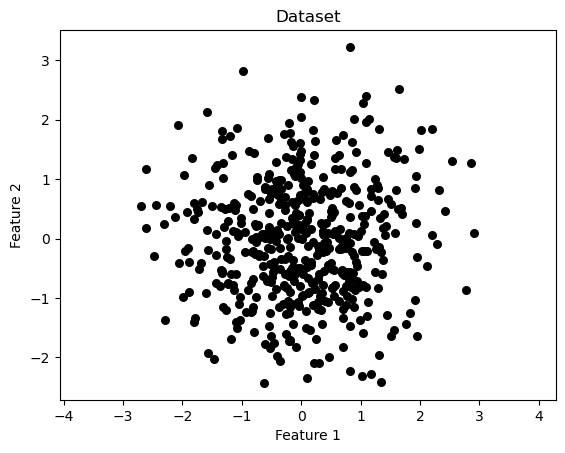

In [3]:
X, _ = make_blobs(n_samples=500, centers=1, n_features=2, cluster_std=1.0, random_state=23)
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

plt.scatter(X[:, 0], X[:, 1], s=30, color='black')
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')
plt.show()

### 1.2

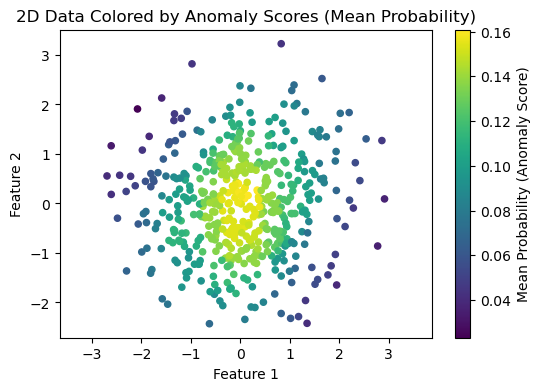

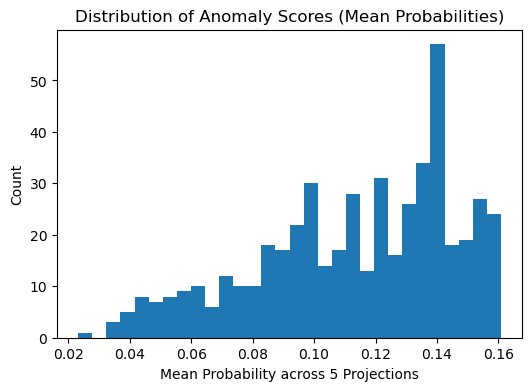

W =  [[ 0.26583167  0.96401946]
 [ 0.5601863  -0.82836665]
 [ 0.77106985 -0.63675057]
 [ 0.98798656  0.15453981]
 [-0.99942032 -0.03404447]]
First 10 Scores =  [0.1196 0.0884 0.1348 0.0728 0.1496 0.0884 0.1012 0.1412 0.0472 0.1428]


In [6]:
num_projections = 5
W = np.random.multivariate_normal(mean=[0, 0], cov = [[1,0],[0,1]], size=num_projections)
W = W / np.linalg.norm(W, axis=1, keepdims=True)

bins = 30
hist_range = (-6.0, 6.0)

projected = [X @ w for w in W]

histograms = []
bin_edges_list = []
bin_probs_list = []
for z in projected:
    counts, edges = np.histogram(z, bins=bins, range=hist_range)
    probs = counts / counts.sum()  # probability mass per bin
    histograms.append(counts)
    bin_edges_list.append(edges)
    bin_probs_list.append(probs)
    
N = X.shape[0]
scores = np.zeros(N)

prob_matrix = np.zeros((N, num_projections))
for j in range(num_projections):
    edges = bin_edges_list[j]
    probs = bin_probs_list[j]
    # vectorized bin lookup
    idxs = np.digitize(projected[j], edges[:-1], right=False) - 1
    idxs = np.clip(idxs, 0, bins - 1)
    prob_matrix[:, j] = probs[idxs]

scores = prob_matrix.mean(axis=1)

# a) Scatter colored by score (lower score = rarer)
plt.figure(figsize=(6.0, 4.0))
plt.scatter(X[:, 0], X[:, 1], c=scores, s=20)
plt.title("2D Data Colored by Anomaly Scores (Mean Probability)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')
plt.colorbar(label="Mean Probability (Anomaly Score)")
plt.show()

plt.figure(figsize=(6.0, 4.0))
plt.hist(scores, bins=30)
plt.title("Distribution of Anomaly Scores (Mean Probabilities)")
plt.xlabel("Mean Probability across 5 Projections")
plt.ylabel("Count")
plt.show()

print("W = ", W)
print("First 10 Scores = ", scores[:10])

### 1.3

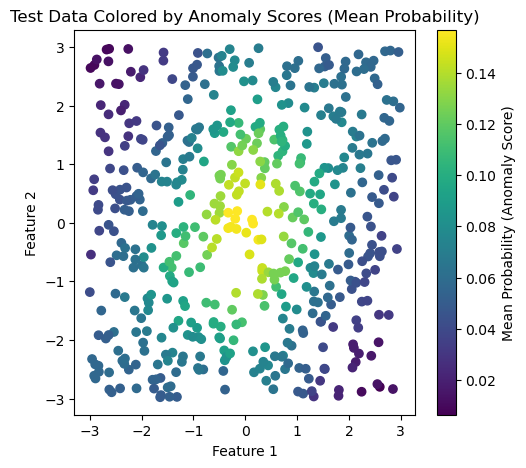

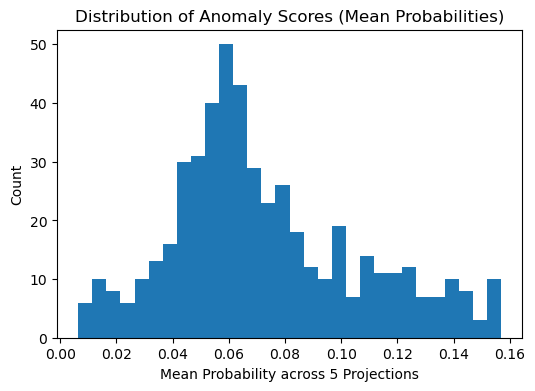

In [7]:
X_test = np.random.uniform(-3, 3, size=(500, 2))
projected_test = [X_test @ w for w in W]

prob_matrix_test = np.zeros((X_test.shape[0], num_projections))
for j in range(num_projections):
    edges = bin_edges_list[j]
    probs = bin_probs_list[j]
    idxs = np.digitize(projected_test[j], edges[:-1], right=False) - 1
    idxs = np.clip(idxs, 0, bins - 1)
    prob_matrix_test[:, j] = probs[idxs]

scores_test = prob_matrix_test.mean(axis=1)

plt.figure(figsize=(5.5, 5.0))
plt.scatter(X_test[:, 0], X_test[:, 1], c=scores_test, cmap='viridis')
plt.title("Test Data Colored by Anomaly Scores (Mean Probability)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Mean Probability (Anomaly Score)")
plt.show()

plt.figure(figsize=(6.0, 4.0))
plt.hist(scores_test, bins=30)
plt.title("Distribution of Anomaly Scores (Mean Probabilities)")
plt.xlabel("Mean Probability across 5 Projections")
plt.ylabel("Count")
plt.show()

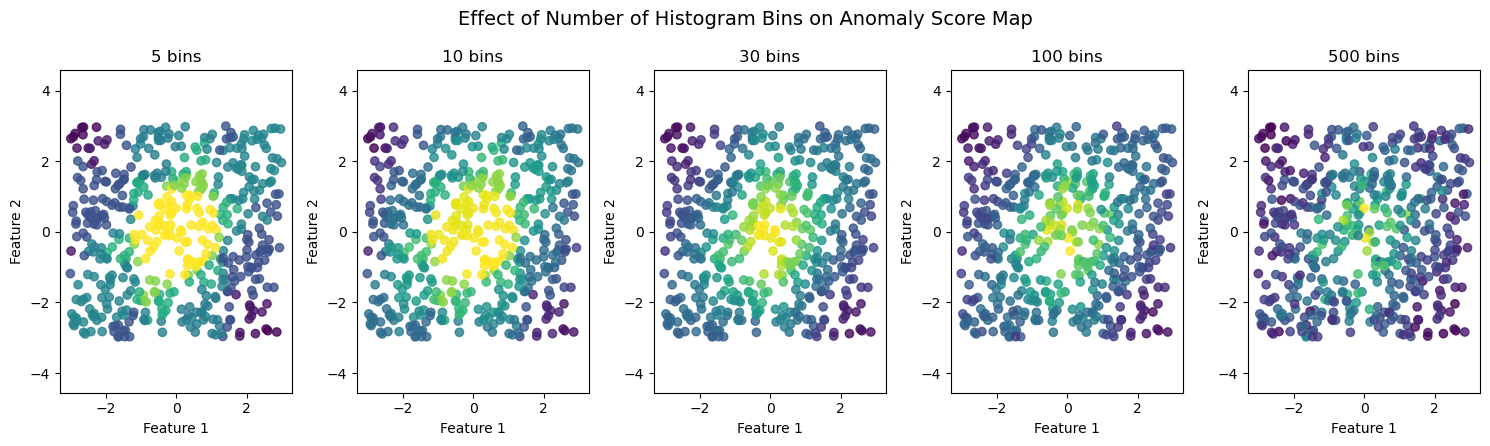

Conclusion: too many bins cand lead to overfitting. too few bins can lead to underfitting. 30-100 bins seem reasonable for this dataset.


In [8]:
bin_counts = [5, 10, 30, 100, 500]

plt.figure(figsize=(15, 4.5))

for i, bins in enumerate(bin_counts):
    hist_range = (-6.0, 6.0)
    projected = [X @ w for w in W]
    bin_edges_list = []
    bin_probs_list = []

    for z in projected:
        counts, edges = np.histogram(z, bins=bins, range=hist_range)
        probs = counts / counts.sum()
        bin_edges_list.append(edges)
        bin_probs_list.append(probs)

    # Compute anomaly scores for test data
    prob_matrix_test = np.zeros((X_test.shape[0], num_projections))
    for j in range(num_projections):
        edges = bin_edges_list[j]
        probs = bin_probs_list[j]
        idxs = np.digitize(projected_test[j], edges[:-1], right=False) - 1
        idxs = np.clip(idxs, 0, bins - 1)
        prob_matrix_test[:, j] = probs[idxs]

    scores_test_bins = prob_matrix_test.mean(axis=1)

    # Plot result
    plt.subplot(1, 5, i + 1)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=scores_test_bins, cmap='viridis', alpha=0.8)
    plt.title(f"{bins} bins")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.axis('equal')

plt.suptitle("Effect of Number of Histogram Bins on Anomaly Score Map", fontsize=14)
plt.tight_layout()
plt.show()

print("Conclusion: too many bins cand lead to overfitting. too few bins can lead to underfitting. 30-100 bins seem reasonable for this dataset.")

# Ex 2

### Ex 2.1

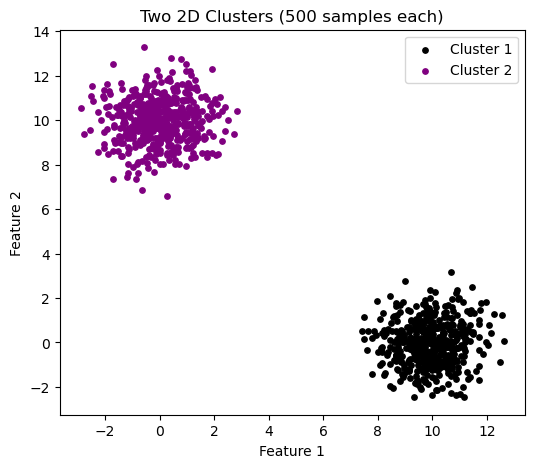

In [10]:
X, y = make_blobs(n_samples=[500, 500],
                  centers=[(10, 0), (0, 10)],
                  cluster_std=1.0,
                  n_features=2,
                  random_state=23)

plt.figure(figsize=(6, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Cluster 1', color='black', s=15)
plt.scatter(X[y==1, 0], X[y==1, 1], label='Cluster 2', color='purple', s=15)
plt.legend()
plt.title("Two 2D Clusters (500 samples each)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Ex 2.2

In [ ]:
iforest = IForest(contamination=0.02, random_state=23)
iforest.fit(X)

X_test = np.random.uniform(-10, 20, size=(1000, 2))

iforest_scores = iforest.decision_function(X_test)
iforest_scores = -iforest_scores

### Ex 2.3

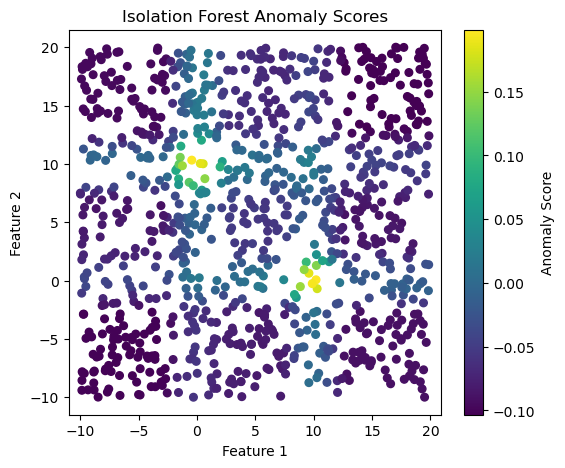

In [38]:
plt.figure(figsize=(6, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=iforest_scores, cmap='viridis', s=30)
plt.colorbar(label="Anomaly Score")
plt.title("Isolation Forest Anomaly Scores")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')
plt.show()

### Ex 2.4

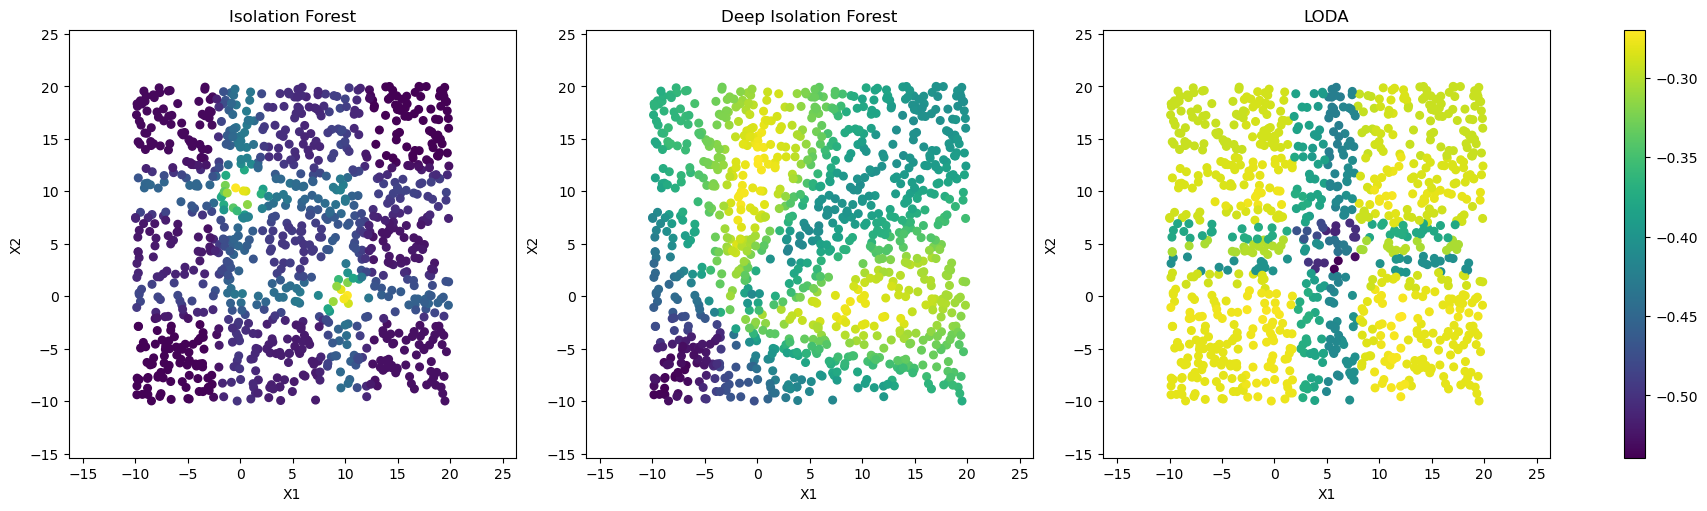

In [40]:
deep_iforest = DIF(contamination=0.2,random_state=23)
deep_iforest.fit(X)
scores_deep_iforest = deep_iforest.decision_function(X_test)

loda = LODA(contamination=0.2)
loda.fit(X)
scores_loda = loda.decision_function(X_test)


fig, axes = plt.subplots(1, 3, figsize=(17, 5),constrained_layout=True)

axes[0].scatter(X_test[:, 0], X_test[:, 1],
                c=iforest_scores, cmap='viridis', s=30)
axes[0].set_title("Isolation Forest")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].axis('equal')

axes[1].scatter(X_test[:, 0], X_test[:, 1],
                c=-scores_deep_iforest, cmap='viridis', s=30)
axes[1].set_title("Deep Isolation Forest")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].axis('equal')

axes[2].scatter(X_test[:, 0], X_test[:, 1],
                c=-scores_loda, cmap='viridis', s=30)
axes[2].set_title("LODA")
axes[2].set_xlabel("X1")
axes[2].set_ylabel("X2")
axes[2].axis('equal')

plt.colorbar(axes[1].collections[0], ax=axes)
plt.show()

### Ex 2.5

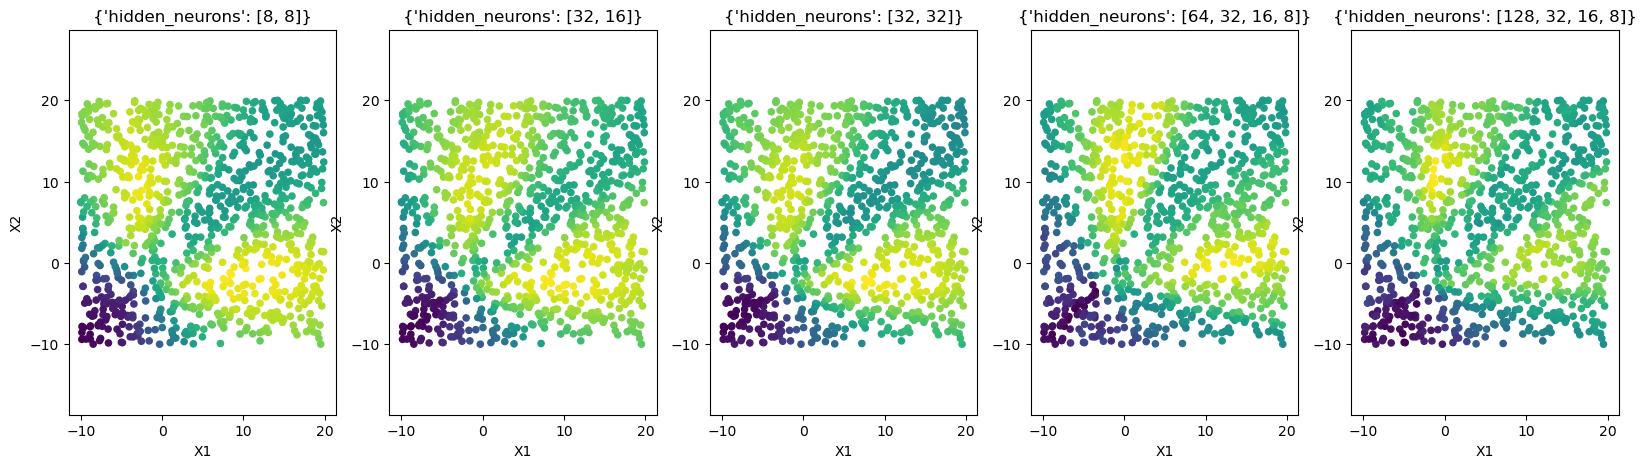

In [41]:
hidden_neurons = [
    {"hidden_neurons": [8, 8]},
    {"hidden_neurons": [32, 16]},
    {"hidden_neurons": [32, 32]},
    {"hidden_neurons": [64, 32, 16, 8]},
    {"hidden_neurons": [128, 32, 16, 8]},
]

fig, axes = plt.subplots(1, len(hidden_neurons), figsize=(20, 5))

for i,neurons in enumerate(hidden_neurons):
    deep_iforest = DIF(contamination=0.2,random_state=23,**neurons)
    deep_iforest.fit(X)
    scores_deep_iforest = deep_iforest.decision_function(X_test)

    axes[i].scatter(X_test[:, 0], X_test[:, 1],c=-scores_deep_iforest, cmap='viridis', s=20)
    axes[i].set_title(f"{neurons}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")
    axes[i].axis('equal')
plt.show()

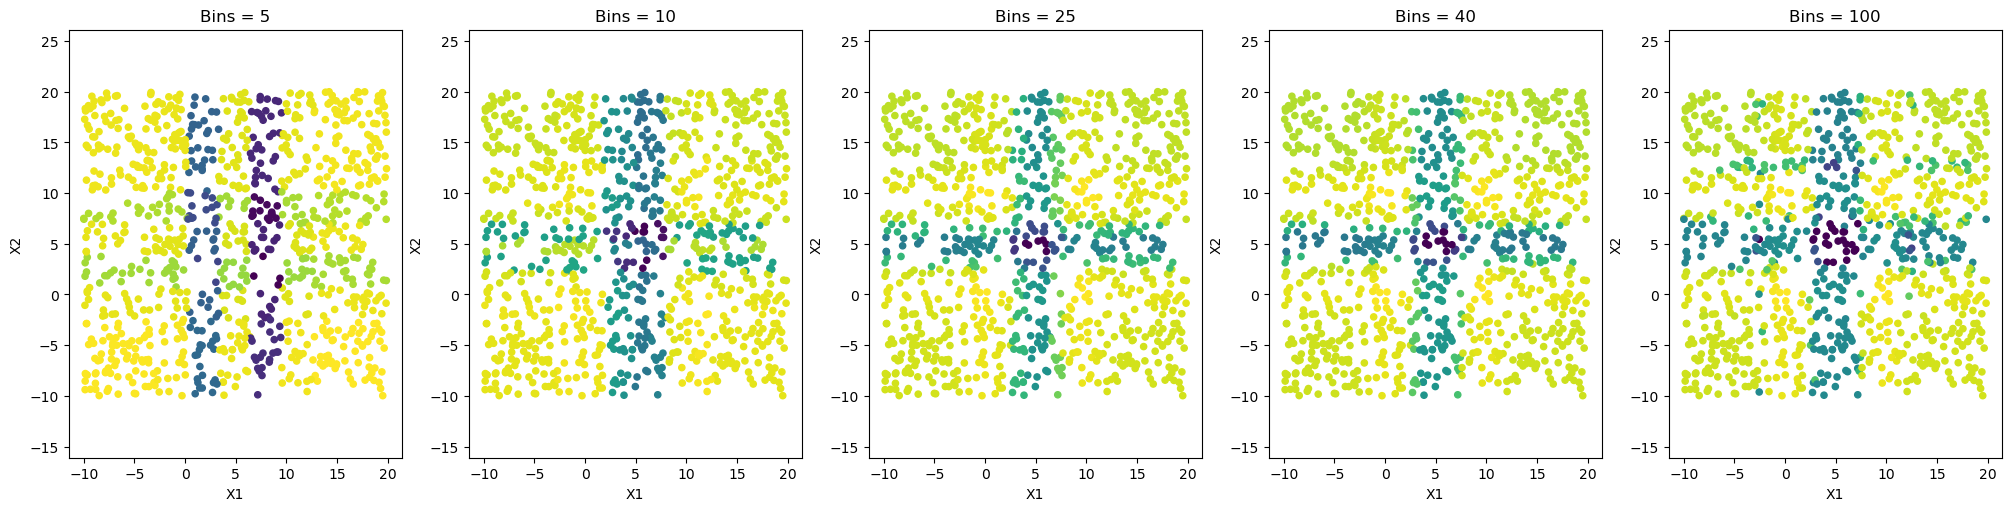

In [42]:
bins = [5,10,25,40, 100]
fig, axes = plt.subplots(1, len(bins), figsize=(20, 5),constrained_layout=True)

for i,bins in enumerate(bins):
    loda_model = LODA(contamination=0.2,n_bins=bins)
    loda_model.fit(X)
    scores_loda_model = loda_model.decision_function(X_test)
    axes[i].scatter(X_test[:, 0], X_test[:, 1], c=-scores_loda_model, cmap='viridis', s=20)
    axes[i].set_title(f"Bins = {bins}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")
    axes[i].axis('equal')
plt.show()

### Ex 2.6

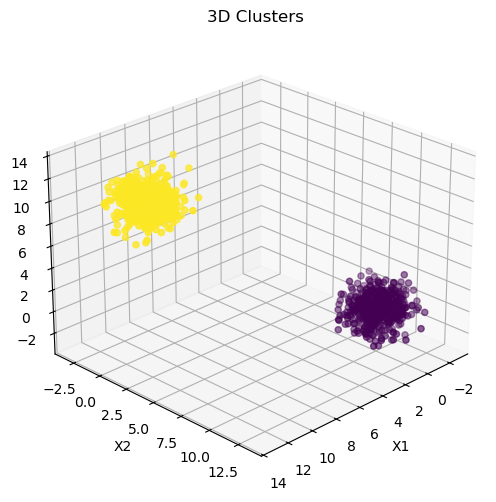

In [55]:
X, y = make_blobs(
    n_samples=[500,500],
    centers=[(0,10,0), (10,0,10)],
    cluster_std=[1,1],
    n_features=3,
    random_state=23,
)

X_test = np.random.uniform(low=-10,high=20,size=(1000,3))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, s=20)

ax.set_title("3D Clusters")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")
ax.view_init(elev=25, azim=45)

plt.show()

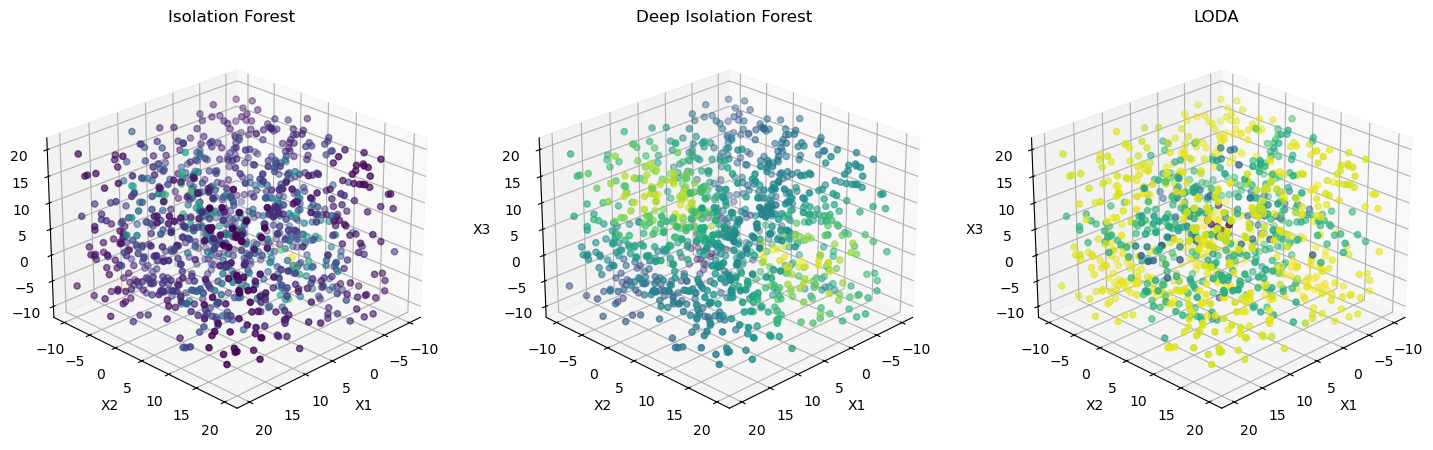

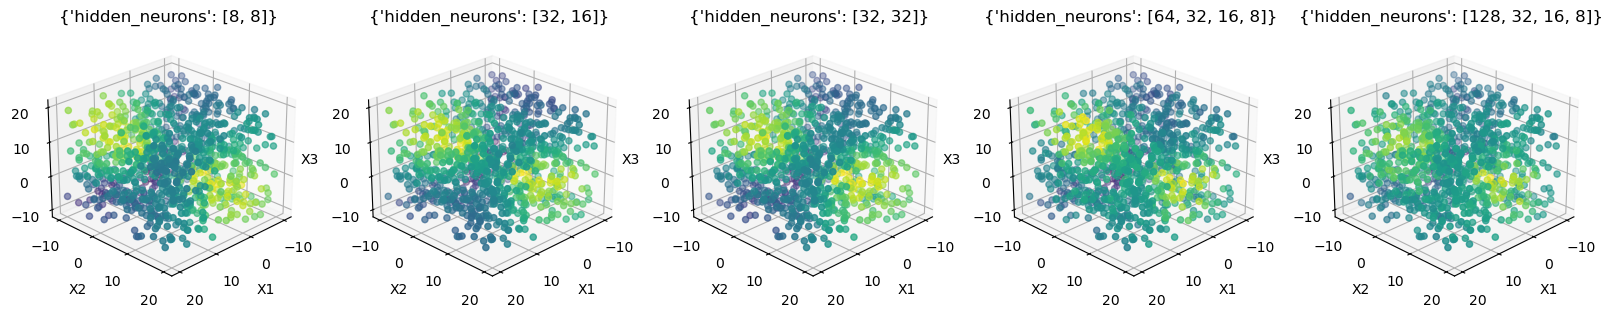

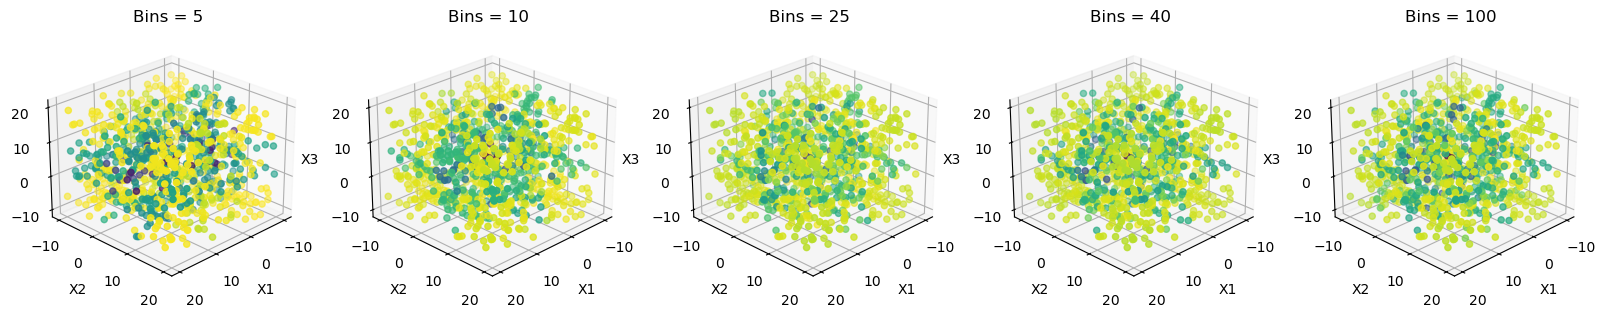

In [58]:
iforest = IForest(contamination=0.02, random_state=23)
iforest.fit(X)
iforest_scores = iforest.decision_function(X_test)

deep_iforest = DIF(contamination=0.2,random_state=23)
deep_iforest.fit(X)
scores_deep_iforest = deep_iforest.decision_function(X_test)

loda = LODA(contamination=0.2)
loda.fit(X)
scores_loda = loda.decision_function(X_test)


fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

p1 = ax1.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2],
                 c=-iforest_scores, cmap='viridis', s=20)
ax1.set_title("Isolation Forest")
ax1.set_xlabel("X1")
ax1.set_ylabel("X2")
ax1.set_zlabel("X3")
ax1.view_init(elev=25, azim=45)


p2 = ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2],
                 c=-scores_deep_iforest, cmap='viridis', s=20)
ax2.set_title("Deep Isolation Forest")
ax2.set_xlabel("X1")
ax2.set_ylabel("X2")
ax2.set_zlabel("X3")
ax2.view_init(elev=25, azim=45)


p3 = ax3.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2],
                 c=-scores_loda, cmap='viridis', s=20)
ax3.set_title("LODA")
ax3.set_xlabel("X1")
ax3.set_ylabel("X2")
ax3.set_zlabel("X3")
ax3.view_init(elev=25, azim=45)


plt.show()


hidden_neurons = [
    {"hidden_neurons": [8, 8]},
    {"hidden_neurons": [32, 16]},
    {"hidden_neurons": [32, 32]},
    {"hidden_neurons": [64, 32, 16, 8]},
    {"hidden_neurons": [128, 32, 16, 8]},
]

fig = plt.figure(figsize=(20, 6))

axes = []
for i in range(len(hidden_neurons)):
    ax = fig.add_subplot(1, len(hidden_neurons), i+1, projection='3d')
    ax.view_init(elev=25, azim=45)
    axes.append(ax)


for i,neurons in enumerate(hidden_neurons):
    deep_iforest = DIF(contamination=0.2,random_state=23,**neurons)
    deep_iforest.fit(X)
    scores_deep_iforest = deep_iforest.decision_function(X_test)

    axes[i].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2],c=-scores_deep_iforest, cmap='viridis', s=20)
    axes[i].set_title(f"{neurons}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")
    axes[i].set_zlabel("X3")
plt.show()

bins = [5,10,25,40, 100]

fig = plt.figure(figsize=(20, 6))
axes = []
for i in range(len(hidden_neurons)):
    ax = fig.add_subplot(1, len(bins), i+1, projection='3d')
    ax.view_init(elev=25, azim=45)
    axes.append(ax)

for i,bins in enumerate(bins):
    loda_model = LODA(contamination=0.2,n_bins=bins)
    loda_model.fit(X)
    scores_loda_model = loda_model.decision_function(X_test)
    axes[i].scatter(X_test[:, 0], X_test[:, 1],X_test[:, 2], c=-scores_loda_model, cmap='viridis', s=20)
    axes[i].set_title(f"Bins = {bins}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")
    axes[i].set_zlabel("X3")
plt.show()

### Ex 3

In [69]:
data = loadmat("shuttle.mat")
X = data["X"]
y = data["y"].ravel().astype(int)

models = {
    "IForest": IForest(random_state=23),
    "DIF": DIF(random_state=23),
    "LODA": LODA(),
}

n = 10
results = {name: {"BA": [], "ROC_AUC": []} for name in models.keys()}

for run in tqdm(range(n)):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=run)

    scaler = StandardScaler().fit(X_train)
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    for name, model in models.items():
        model.fit(X_train)

        y_pred = model.predict(X_test)
        y_scores = model.decision_function(X_test)

        ba = balanced_accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_scores)
        results[name]["BA"].append(ba)
        results[name]["ROC_AUC"].append(roc_auc)


print(f"BA + ROC AUC --> {n} runs")
for name in models.keys():
    mean_ba = np.mean(results[name]["BA"])
    mean_auc = np.mean(results[name]["ROC_AUC"])
    print(f"{name:20s} | BA: {mean_ba:.3f} | ROC AUC: {mean_auc:.3f}")

100%|██████████| 10/10 [10:13<00:00, 61.37s/it]

BA + ROC AUC --> 10 runs
IForest              | BA: 0.977 | ROC AUC: 0.997
DIF                  | BA: 0.518 | ROC AUC: 0.968
LODA                 | BA: 0.575 | ROC AUC: 0.486
